# Анализ датасетов решений уравнения Матье с запаздыванием

## Импорт библиотек

In [1]:
import os
import pickle
import sys
import numpy as np
import pandas as pd
from scipy import signal, fft
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from scipy.ndimage import maximum_filter1d
from matplotlib.colors import LogNorm
from tqdm import tqdm

# Настройка отображения графиков
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## Загрузка датасетов

In [2]:
datasets_dir = "datasets/"
dataset_files = [f for f in os.listdir(datasets_dir) if f.endswith('shrink.pkl') and f.startswith('mathieu')]
# dataset_files = [f for f in os.listdir(dataset_files) if f.startswith('mathieu')]

print("Найдены датасеты:")
for f in dataset_files:
    print(f"- {f}")

# Загрузка всех датасетов
datasets = {}
for file in tqdm(dataset_files, desc="Загрузка датасетов"):
    path = os.path.join(datasets_dir, file)
    with open(path, 'rb') as f:
        datasets[file] = pickle.load(f)

Найдены датасеты:
- mathieu_delayed_dataset_shrink.pkl


Загрузка датасетов: 100%|██████████| 1/1 [00:01<00:00,  1.32s/it]


In [3]:
datasets["mathieu_delayed_dataset_shrink.pkl"].keys()

dict_keys(['trajectories', 'config', 'stats', 'generation_info'])

In [4]:
len(datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"])

2000

In [5]:
datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]

{'id': 0,
 'parameters': {'k': 0.181,
  'd': 2.5,
  'e': 0,
  'tau': 6.283185307179586,
  'T': 6.283185307179586,
  'F_ts': 0,
  'F_te': 10,
  'F_T': 2.0943951023931953,
  'b': 0.343905080314186,
  'b_e': 0.41721514930979353,
  'nonlin_k': 0.042055267521432876,
  'F_As': 3.8473095986778096,
  'F_Ae': 3.8473095986778096,
  'b_ts': 1937.6823391999683,
  'b_te': 2312.7616337880777},
 'solution': {'t': array([0.0000e+00, 1.0000e-01, 2.0000e-01, ..., 4.9997e+03, 4.9998e+03,
         4.9999e+03]),
  'x': array([ 0.19029354, -0.05359788, -0.28377336, ..., -0.82163183,
         -0.24950955,  0.3651857 ]),
  'x_dot': array([-2.45200698, -2.3975825 , -2.18011643, ...,  5.46096169,
          5.95971629,  6.3047673 ])},
 'metadata': {'max_amplitude': 4.227072454129368,
  'mean_amplitude': 0.9265159025777984,
  'std_amplitude': 1.4198854962583454,
  'duration': 4999.990000064886,
  'num_points': 500000,
  'sampling_rate': 99.99999999994884,
  'mean_period': 2.4271865889527775,
  'std_period': 0.685

In [6]:
datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]["metadata"]

{'max_amplitude': 4.227072454129368,
 'mean_amplitude': 0.9265159025777984,
 'std_amplitude': 1.4198854962583454,
 'duration': 4999.990000064886,
 'num_points': 500000,
 'sampling_rate': 99.99999999994884,
 'mean_period': 2.4271865889527775,
 'std_period': 0.6851563101226948,
 'num_peaks': 2059}

(0.0, 5010.0)

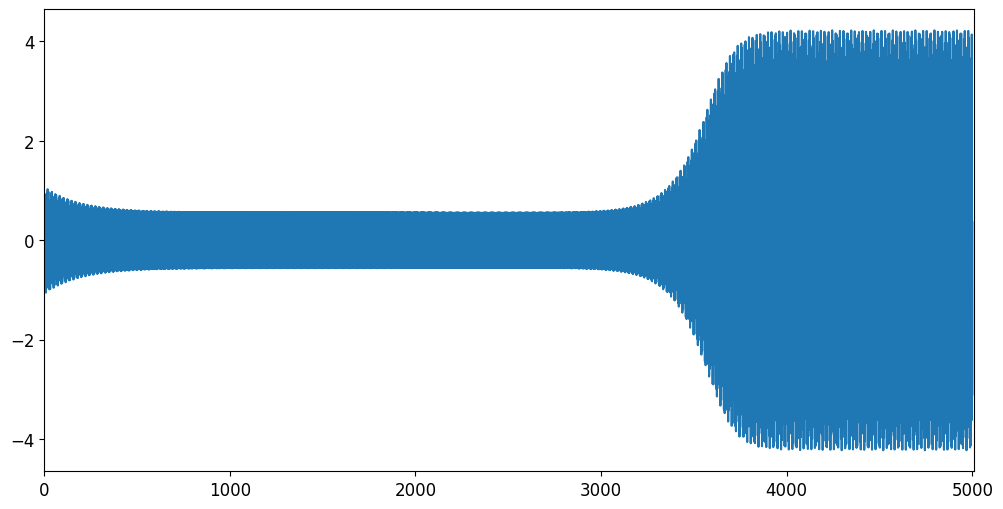

In [179]:
traj = datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]
x = np.array(traj["solution"]["x"])
t = np.array(traj["solution"]["t"])
x_dot = np.array(traj["solution"]["x_dot"])
r = find_peaks(x)[0]
plt.plot(t, x)

plt.xlim(0, 5010)

(0.0, 5010.0)

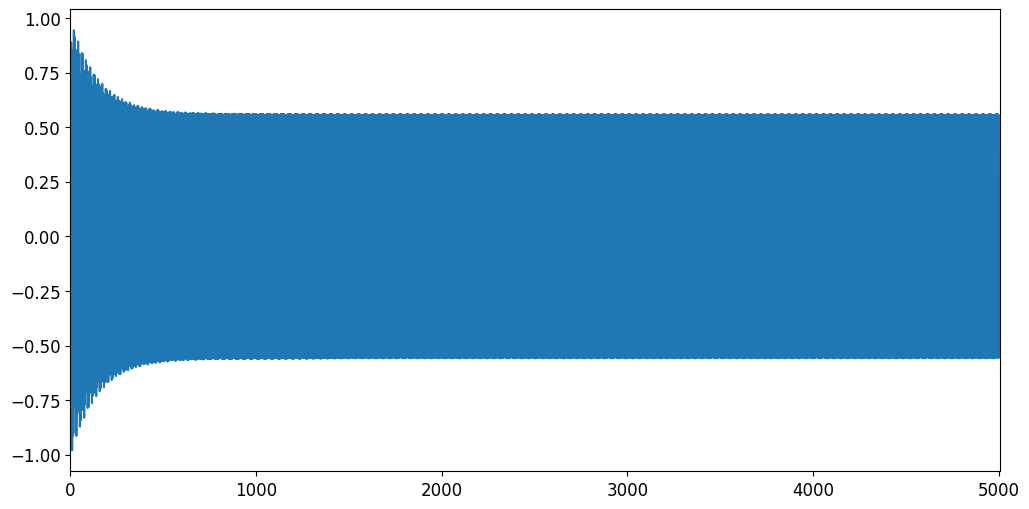

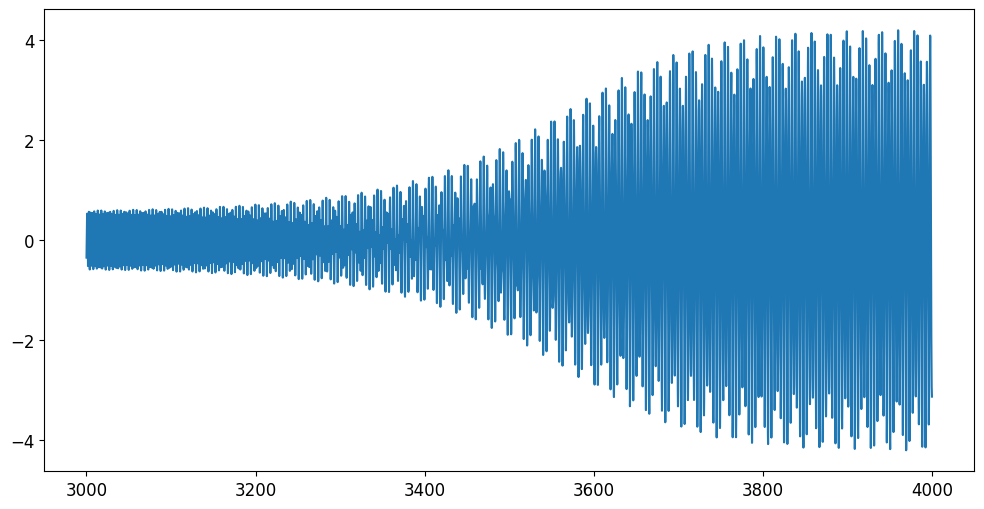

In [36]:
plt.plot(t[(t > 3000) & (t < 4000)], x[(t > 3000) & (t < 4000)])

In [37]:
len(t[(t > 3000) & (t < 4000)])

10000

In [35]:
np.max(datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]["solution"]["x"][r])

np.float64(4.225801735892323)

In [ ]:
# for tr in datasets["mathieu_delayed_dataset.pkl"]["trajectories"]:
#     tr["solution"]["t"] = tr["solution"]["t"][::10]
#     tr["solution"]["x"] = tr["solution"]["x"][::10]
#     tr["solution"]["x_dot"] = tr["solution"]["x_dot"][::10]

In [ ]:
# with open("datasets/mathieu_delayed_dataset_shrink.pkl", "wb") as f:
#     pickle.dump(datasets["mathieu_delayed_dataset.pkl"], f)

In [24]:
a = [1, 2, 3, 4, 5]
a[::2]

[1, 3, 5]

In [5]:
# datasets

## Масштаб изменений амплитуд

In [30]:
traj = datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][3]
x = np.array(traj["solution"]["x"])
t = np.array(traj["solution"]["t"])
x_dot = np.array(traj["solution"]["x_dot"])
indices, properties = find_peaks(x, distance=50)
envelope = maximum_filter1d(x, size=300)
t_max = t[indices]
x_max = x[indices]
diff = (np.max(x_max) - np.min(x_max)) / (np.max(x))
diff_2 = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
diff, len(indices), diff_2

(np.float64(0.8529059587503619), 634, np.float64(0.850373123921969))

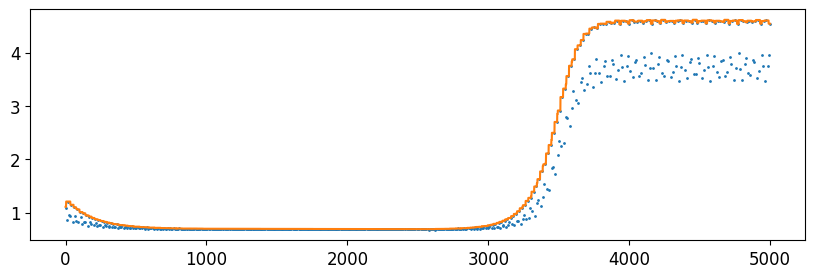

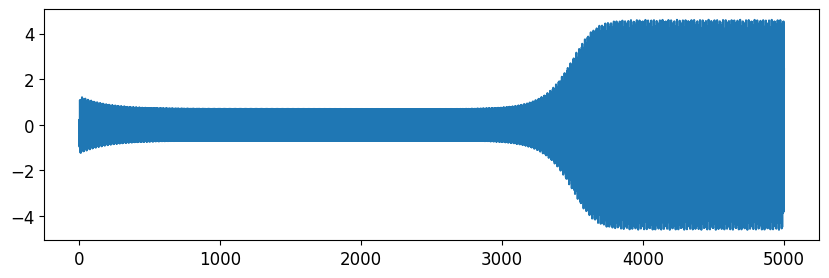

In [31]:
plt.figure(figsize=(10, 3))
plt.plot(t_max, x_max, 'o', markersize=1)
plt.plot(t, envelope,)
plt.figure(figsize=(10, 3))
plt.plot(t, x)
# plt.xlim(0, 200)

In [32]:
# plt.figure(figsize=(10, 3))
# plt.plot(t_max, x_max, 'o', markersize=1)
# plt.figure(figsize=(10, 3))
# plt.plot(t, x)
# plt.xlim(3000, 3600)

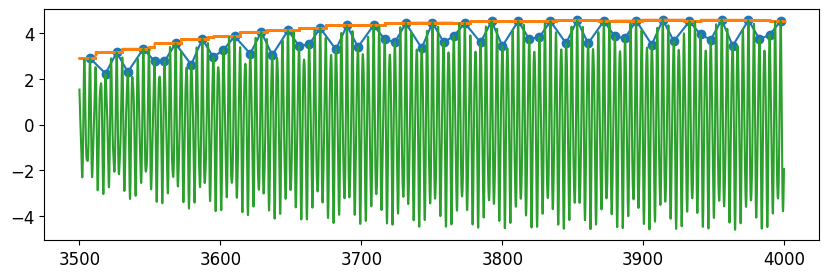

In [33]:
plt.figure(figsize=(10, 3))
plt.plot(t_max[(t_max > 3500) & (t_max < 4000)], x_max[(t_max > 3500) & (t_max < 4000)], '-o')
plt.plot(t[(t > 3500) & (t < 4000)], envelope[(t > 3500) & (t < 4000)], '-o', markersize=1)
plt.plot(t[(t > 3500) & (t < 4000)], x[(t > 3500) & (t < 4000)])
# plt.xlim(0, 200)

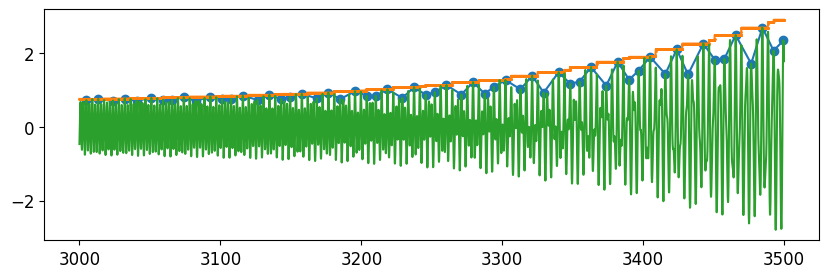

In [34]:
plt.figure(figsize=(10, 3))
plt.plot(t_max[(t_max > 3000) & (t_max < 3500)], x_max[(t_max > 3000) & (t_max < 3500)], '-o')
plt.plot(t[(t > 3000) & (t < 3500)], envelope[(t > 3000) & (t < 3500)], '-o', markersize=1)
plt.plot(t[(t > 3000) & (t < 3500)], x[(t > 3000) & (t < 3500)])
# plt.xlim(0, 200)

50 0.16384443795502354


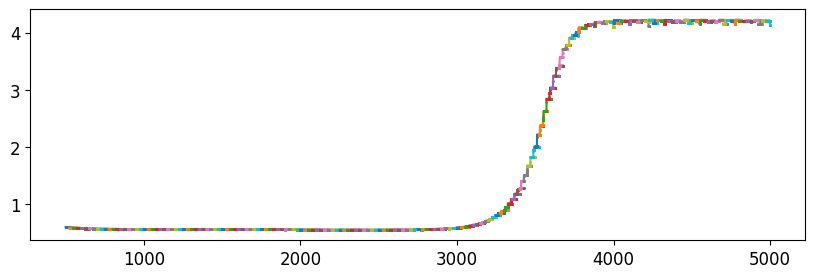

100 0.3053900440268764


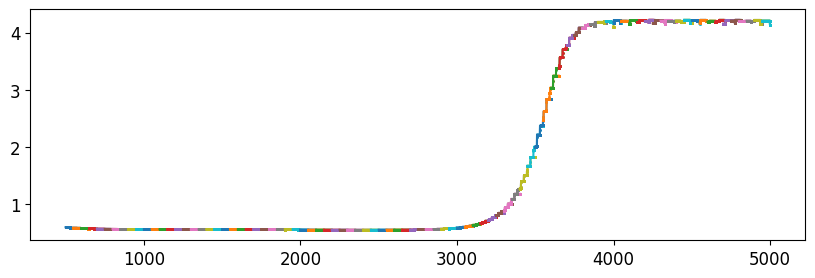

200 0.5524882542143073


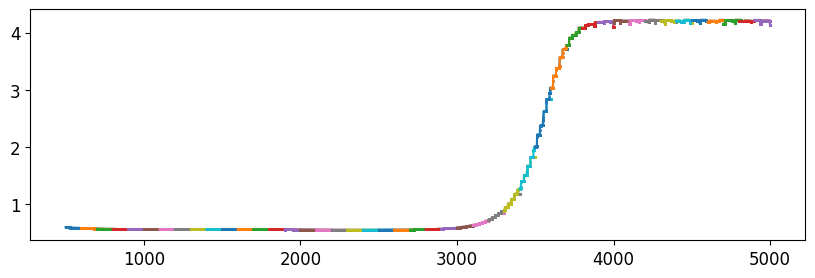

300 0.6636333252173002


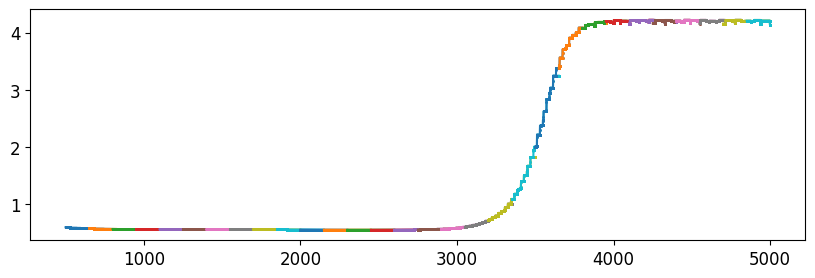

500 0.7946365942106112


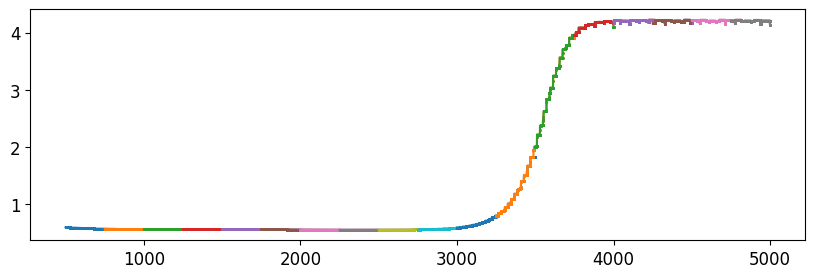

800 0.8463454514664158


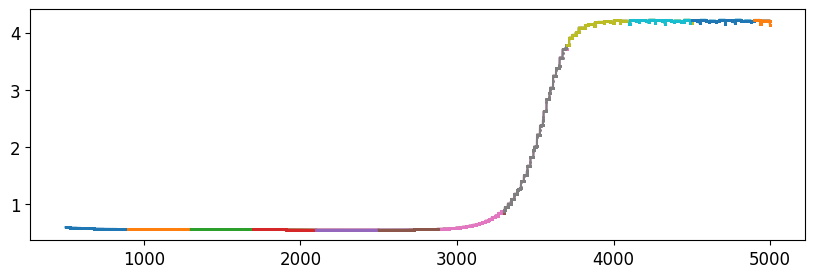

1000 0.8591051690309093


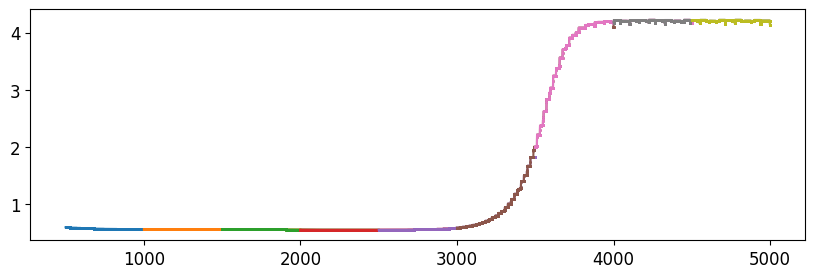

5000 0.8687869766700448


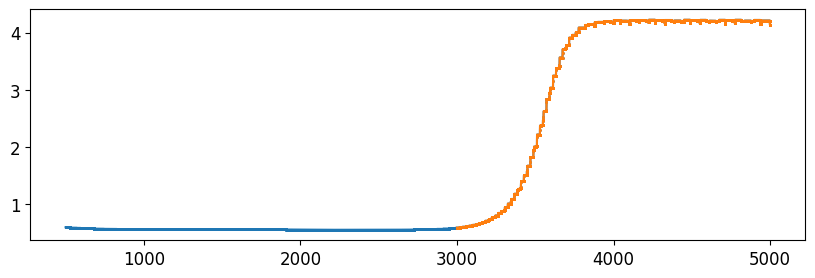

([50, 100, 200, 300, 500, 800, 1000, 5000],
 [np.float64(0.16384443795502354),
  np.float64(0.3053900440268764),
  np.float64(0.5524882542143073),
  np.float64(0.6636333252173002),
  np.float64(0.7946365942106112),
  np.float64(0.8463454514664158),
  np.float64(0.8591051690309093),
  np.float64(0.8687869766700448)])

In [42]:

window_sizes_t = [50, 100, 200, 300, 500, 800, 1000, 5000]
# window_sizes_t = [50]
traj = datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]
x = np.array(traj["solution"]["x"])[5000:]
t = np.array(traj["solution"]["t"])[5000:]
max_diffs = []
for window_size_t in window_sizes_t:
    plt.figure(figsize=(10, 3))
    n_samples = int(window_size_t / 0.1)
    stride = int(n_samples / 2)
    diffs = []
    for start_idx in range(0, len(t), stride):
        end_idx = start_idx + n_samples

        # indices, properties = find_peaks(x[start_idx:end_idx], distance=50)
        # t_max = t[start_idx:end_idx][indices]
        # x_max = x[start_idx:end_idx][indices]
        # plt.plot(t_max, x_max, '-o')
        # diff = (np.max(x_max) - np.min(x_max)) / (np.max(x))


        envelope = maximum_filter1d(x[start_idx:end_idx], size=400)
        diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
        plt.plot(t[start_idx:end_idx], envelope, '-o', markersize=1)
        diffs.append(diff)
    max_diffs.append(np.max(diffs))
    print(window_size_t, np.max(diffs))
    plt.show()
window_sizes_t, max_diffs

In [40]:
envelope.shape, t[start_idx:end_idx].shape

((500,), (500,))

In [243]:
50 / 0.1

500.0

In [152]:
500 / 0.1, len(t)

(5000.0, 45000)

In [53]:
int(500 / 5)

100

In [56]:
500 * 5

2500

In [54]:
5000 / 5

1000.0

In [44]:
diffs = []
for traj in tqdm(datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"]):
    x = np.array(traj["solution"]["x"])[5000:]
    t = np.array(traj["solution"]["t"])[5000:]
    # indices, properties = find_peaks(x, distance=50)
    # t_peaks = t[indices]
    # x_peaks = x[indices]
    # diff = (np.max(x_peaks) - np.min(x_peaks)) / (np.max(x))

    envelope = maximum_filter1d(x[start_idx:end_idx], size=400)
    diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
    diffs.append(diff)
    # if diff > 0.3 and diff < 0.4:
    # if diff > 0.6 and diff < 0.7:
    #     break
diffs = np.array(diffs)

100%|██████████| 2000/2000 [00:00<00:00, 4242.33it/s]


0.2935

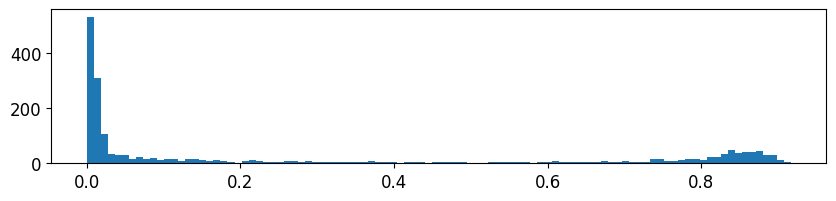

In [46]:
plt.figure(figsize=(10, 2))
plt.hist(diffs, bins=100);
len(diffs[diffs > 0.5]) / len(diffs)

np.float64(0.09613566227350047)

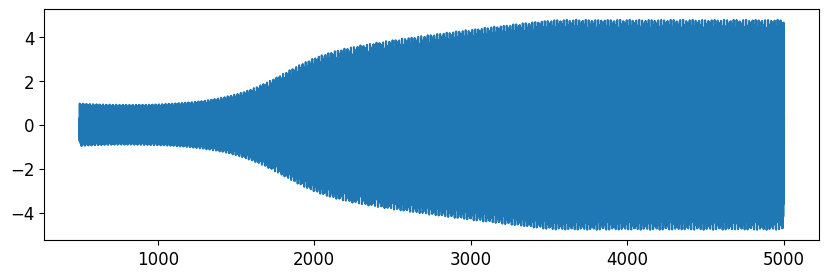

In [47]:
plt.figure(figsize=(10, 3))
plt.plot(t[0:], x[0:])
diff

In [48]:
window_sizes_t = [50, 100, 200, 300, 400, 500, 600, 800, 1000, 5000]

res_w_w = []
res_max_diff_w = []
for window_size_t in window_sizes_t:
    res_w = []
    res_max_diff = []
    for traj in tqdm(datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"]):
        x = np.array(traj["solution"]["x"])[5000:]
        t = np.array(traj["solution"]["t"])[5000:]
        n_samples = int(window_size_t / 0.1)
        stride = int(n_samples / 2)
        diffs = []
        for start_idx in range(0, len(t), stride):
            end_idx = start_idx + n_samples

            # indices, properties = find_peaks(x[start_idx:end_idx], distance=50)
            # t_max = t[start_idx:end_idx][indices]
            # x_max = x[start_idx:end_idx][indices]
            # diff = (np.max(x_max) - np.min(x_max)) / (np.max(x))

            envelope = maximum_filter1d(x[start_idx:end_idx], size=400)
            diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
            diffs.append(diff)
        max_diff = np.max(diffs)
        res_w.append(window_size_t)
        res_max_diff.append(max_diff)
    res_w_w.append(res_w)
    res_max_diff_w.append(res_max_diff)


100%|██████████| 2000/2000 [00:00<00:00, 2154.32it/s]


In [49]:
res_w_w = np.array(res_w_w)
res_max_diff_w = np.array(res_max_diff_w)
res_w_w.shape, res_max_diff_w.shape

((10, 2000), (10, 2000))

50 79.39796614380418
100 69.49825491754632
200 50.995745735912
300 37.185637917150856
400 31.03674546710005
500 25.33389907545865
600 20.51644241412793
800 16.20266522149283
1000 11.780563810239258


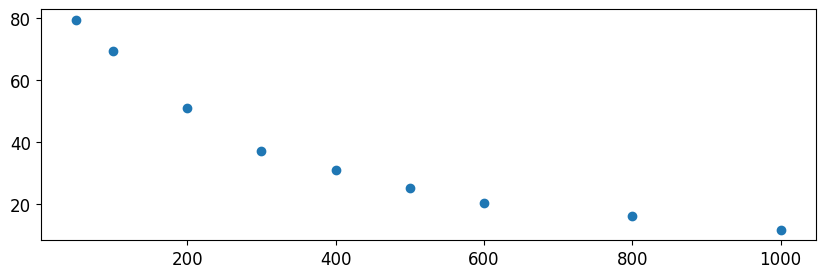

In [50]:
diffs = np.abs(res_max_diff_w[:-1] - res_max_diff_w[-1]) / res_max_diff_w[-1] * 100
x = []
y = []
for i in range(len(diffs)):
    print(window_sizes_t[i], np.mean(diffs[i]))
    x.append(window_sizes_t[i])
    y.append(np.mean(diffs[i]))
plt.figure(figsize=(10, 3))
plt.plot(x, y, 'o')

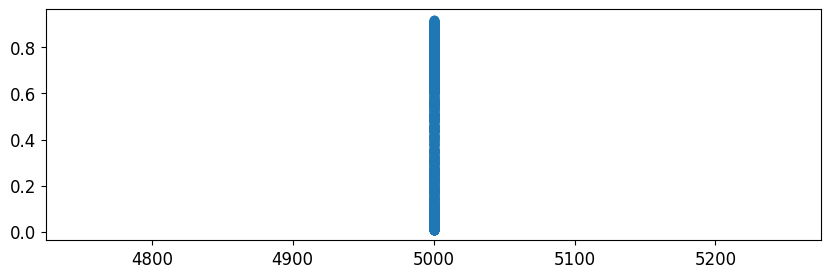

In [51]:
plt.figure(figsize=(10, 3))
plt.plot(res_w, res_max_diff, 'o')
plt.show()


## Частота дискретизации

In [434]:
traj = datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"][0]
x = np.array(traj["solution"]["x"])
t = np.array(traj["solution"]["t"])
x_dot = np.array(traj["solution"]["x_dot"])
indices, properties = find_peaks(x, distance=50)
t_max = t[indices]
x_max = x[indices]
diff = (np.max(x_max) - np.min(x_max)) / (np.max(x))
diff, len(indices)

(np.float64(0.8704459336492284), 638)

In [435]:
frequencies, times, Sxx = signal.spectrogram(
    np.array(x),
    fs=1 / 0.1,
    nperseg=min(1024, len(x)//10),
    window='hann',
    noverlap=512
)
Sxx /= Sxx.sum(axis=0, keepdims=True) + 1e-12
# Находим максимальную значимую частоту в каждый момент времени
max_freqs = frequencies[np.argmax(Sxx, axis=0)]
np.max(max_freqs)

np.float64(0.478515625)

In [436]:
frequencies.shape, times.shape, Sxx.shape

((513,), (96,), (513, 96))

In [437]:
# plt.imshow(Sxx)

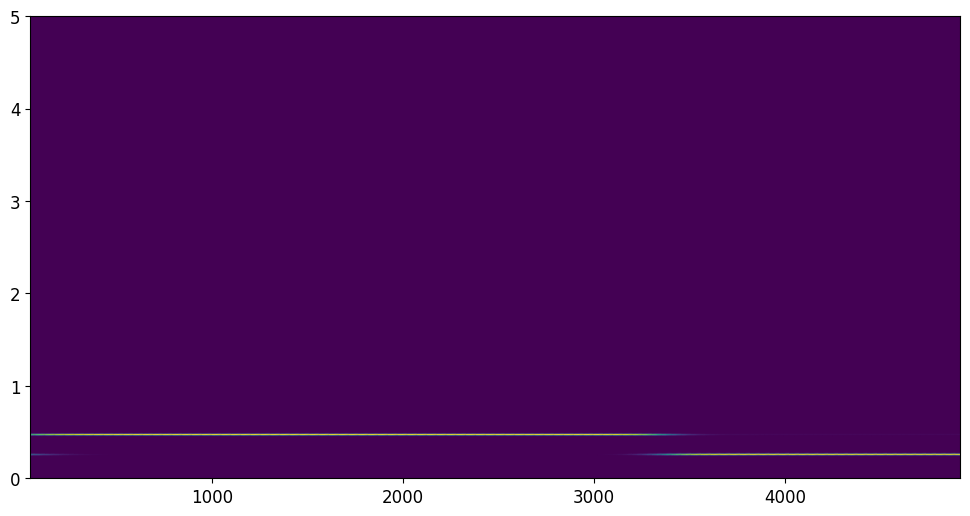

In [438]:
plt.pcolormesh(times, frequencies, Sxx, shading='gouraud')
plt.show()

In [449]:
original_rate = 1 / 0.1
target_sampling_rate = np.max(max_freqs) * 2 * 5
target_sampling_rate = 5

upsample_factor = target_sampling_rate / original_rate
t_resampled = np.linspace(t[0], t[-1], int(len(t) * upsample_factor))
x_resampled = np.interp(t_resampled, t, x)
print(original_rate, target_sampling_rate)

10.0 5


In [450]:
np.max(max_freqs) * 2 * 5

np.float64(4.78515625)

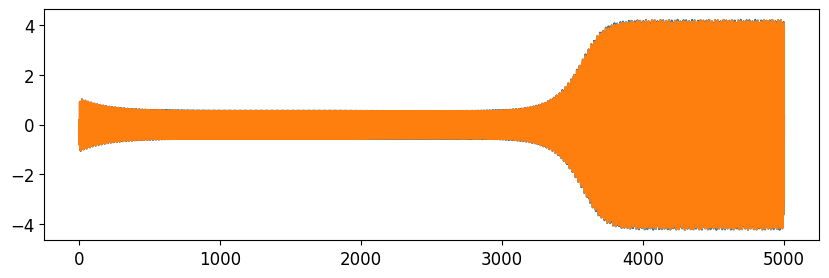

In [451]:
plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.plot(t_resampled, x_resampled)
# plt.xlim(500, 1000)


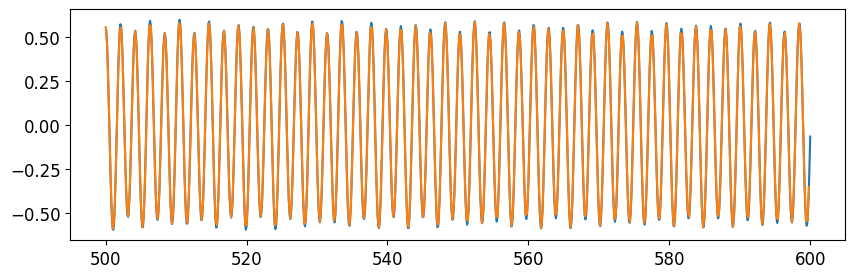

In [453]:
plt.figure(figsize=(10, 3))
plt.plot(t[(t>500) & (t<600)], x[(t>500) & (t<600)])
plt.plot(t_resampled[(t_resampled>500) & (t_resampled<600)], x_resampled[(t_resampled>500) & (t_resampled<600)])
# plt.xlim(500, 600)


(4000.0, 4100.0)

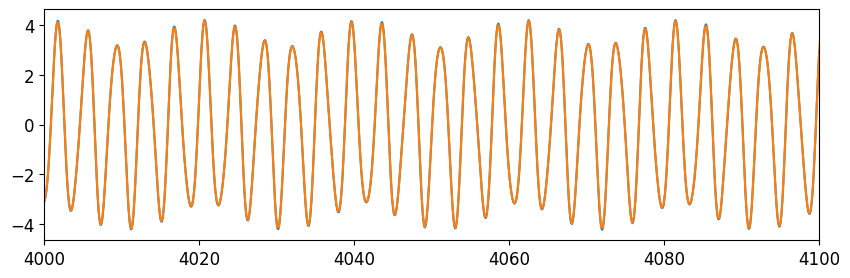

In [454]:
plt.figure(figsize=(10, 3))
plt.plot(t, x)
plt.plot(t_resampled, x_resampled)
plt.xlim(4000, 4100)


In [426]:
max_freqs = []
for traj in tqdm(datasets["mathieu_delayed_dataset_shrink.pkl"]["trajectories"]):
    x = np.array(traj["solution"]["x"])
    frequencies, times, Sxx = signal.spectrogram(
        np.array(x),
        fs=1 / 0.1,
        nperseg=min(1024, len(x)//10),
        window='hann',
        noverlap=512
    )
    Sxx /= Sxx.sum(axis=0, keepdims=True) + 1e-12
    # Находим максимальную значимую частоту в каждый момент времени
    max_freqs.append(np.max(frequencies[np.argmax(Sxx, axis=0)]))

100%|██████████| 2000/2000 [00:02<00:00, 955.78it/s]


In [456]:
5, 1/ 5

(5, 0.2)

In [459]:
600 / 0.1, 600 / 0.2

(6000.0, 3000.0)

## Анализ метаданных датасетов

In [38]:
def extract_dataset_info(dataset):
    """Извлекает основную информацию о датасете"""
    return {
        "num_trajectories": len(dataset['trajectories']),
        "success_rate": dataset['generation_info']['success_rate'],
        "generation_time": dataset['generation_info']['generation_time'],
        "file_size": os.path.getsize(os.path.join(datasets_dir, file)) / (1024 * 1024)
    }

# Создаем DataFrame с информацией о датасетах
dataset_info = []
for file, data in datasets.items():
    info = extract_dataset_info(data)
    info["dataset_name"] = file
    dataset_info.append(info)

df_info = pd.DataFrame(dataset_info)
df_info

,num_trajectories,success_rate,generation_time,file_size,dataset_name
0,2000,1.0,962.039841,2290.028258,mathieu_delayed_dataset_shrink.pkl


## Визуализация статистики датасетов

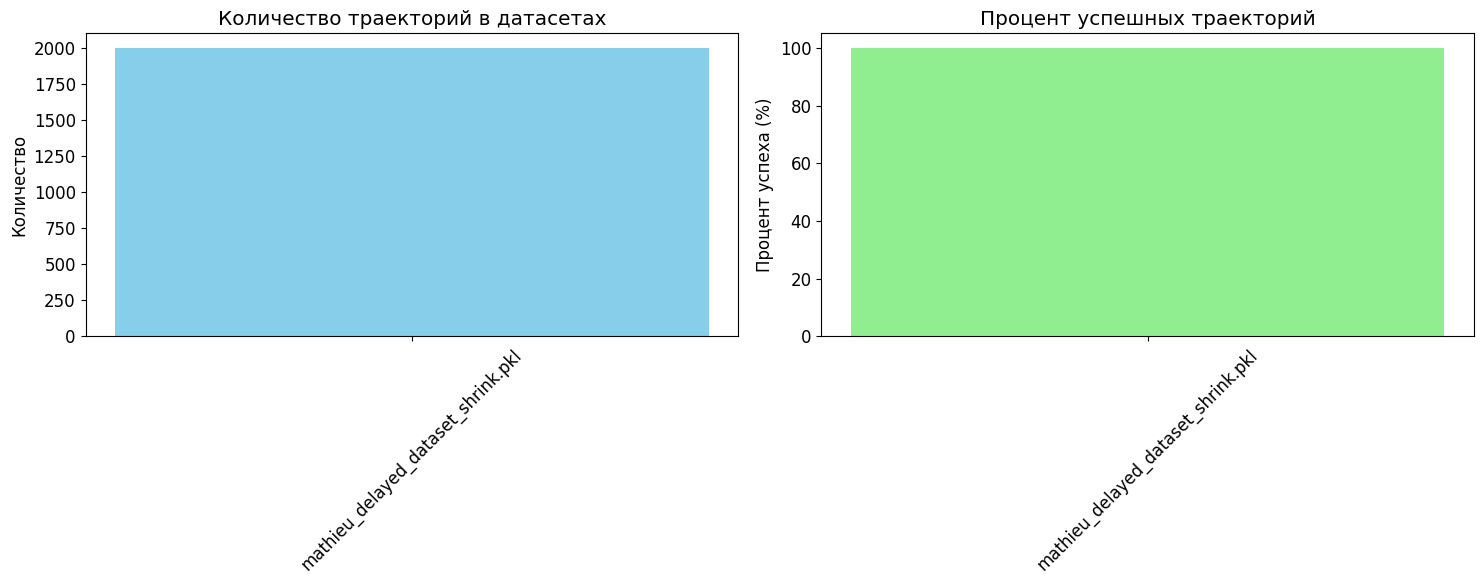

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Количество траекторий
axes[0].bar(df_info['dataset_name'], df_info['num_trajectories'], color='skyblue')
axes[0].set_title('Количество траекторий в датасетах')
axes[0].set_ylabel('Количество')
axes[0].tick_params(axis='x', rotation=45)

# Процент успеха
axes[1].bar(df_info['dataset_name'], df_info['success_rate']*100, color='lightgreen')
axes[1].set_title('Процент успешных траекторий')
axes[1].set_ylabel('Процент успеха (%)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Анализ параметров траекторий

In [40]:
def extract_trajectory_data(trajectory):
    """Извлекает параметры и метаданные траектории"""
    params = trajectory['parameters']
    meta = trajectory['metadata']
    solution = trajectory['solution']
    idx_peaks = find_peaks(solution["x"])[0]
    max_peak = solution["x"][idx_peaks].max()
    min_peak = solution["x"][idx_peaks].min()

    return {
        # 'k': params.get('k'),
        # 'd': params.get('d'),
        # 'e': params.get('e'),
        'b': params.get('b'),
        'b_e': params.get('b_e'),
        'b_ts': params.get('b_ts'),
        'b_te': params.get('b_te'),
        'F_As': params.get('F_As'),
        # 'tau': params.get('tau'),
        'nonlin_k': params.get('nonlin_k'),
        'max_amplitude': meta.get('max_amplitude'),
        'mean_amplitude': meta.get('mean_amplitude'),
        'duration': meta.get('duration'),
        'num_points': meta.get('num_points'),
        'max_peak': max_peak,
        'min_peak': min_peak,
        'diff_peak': max_peak - min_peak,
    }

# Создаем DataFrame со всеми траекториями
all_trajectories = []
for dataset_name, dataset in datasets.items():
    for traj in dataset['trajectories']:
        data = extract_trajectory_data(traj)
        data['dataset'] = dataset_name
        all_trajectories.append(data)

df_traj = pd.DataFrame(all_trajectories)
df_traj.head()

,b,b_e,b_ts,b_te,F_As,nonlin_k,max_amplitude,mean_amplitude,duration,num_points,max_peak,min_peak,diff_peak,dataset
0,0.343905,0.417215,1937.682339,2312.761634,3.847310,0.042055,4.227072,0.926516,4999.99,500000,4.225802,-0.902924,5.128726,mathieu_delayed_dataset_shrink.pkl
1,0.333362,0.417626,277.015784,1558.780634,3.293512,0.030002,4.889912,1.931363,4999.99,500000,4.887625,-0.540769,5.428394,mathieu_delayed_dataset_shrink.pkl
2,0.334880,0.362074,991.004463,1613.945902,3.840736,0.040993,0.980219,0.356374,4999.99,500000,0.943598,0.172789,0.770809,mathieu_delayed_dataset_shrink.pkl
3,0.344064,0.416652,1376.755931,2688.879267,4.785894,0.035818,4.614852,1.062436,4999.99,500000,4.614830,-0.895265,5.510094,mathieu_delayed_dataset_shrink.pkl
4,0.377362,0.403779,648.268487,3928.823364,4.395458,0.049454,3.414471,1.300591,4999.99,500000,3.412669,-1.155036,4.567705,mathieu_delayed_dataset_shrink.pkl


In [41]:
# traj["metadata"].keys()

## Визуализация распределения параметров

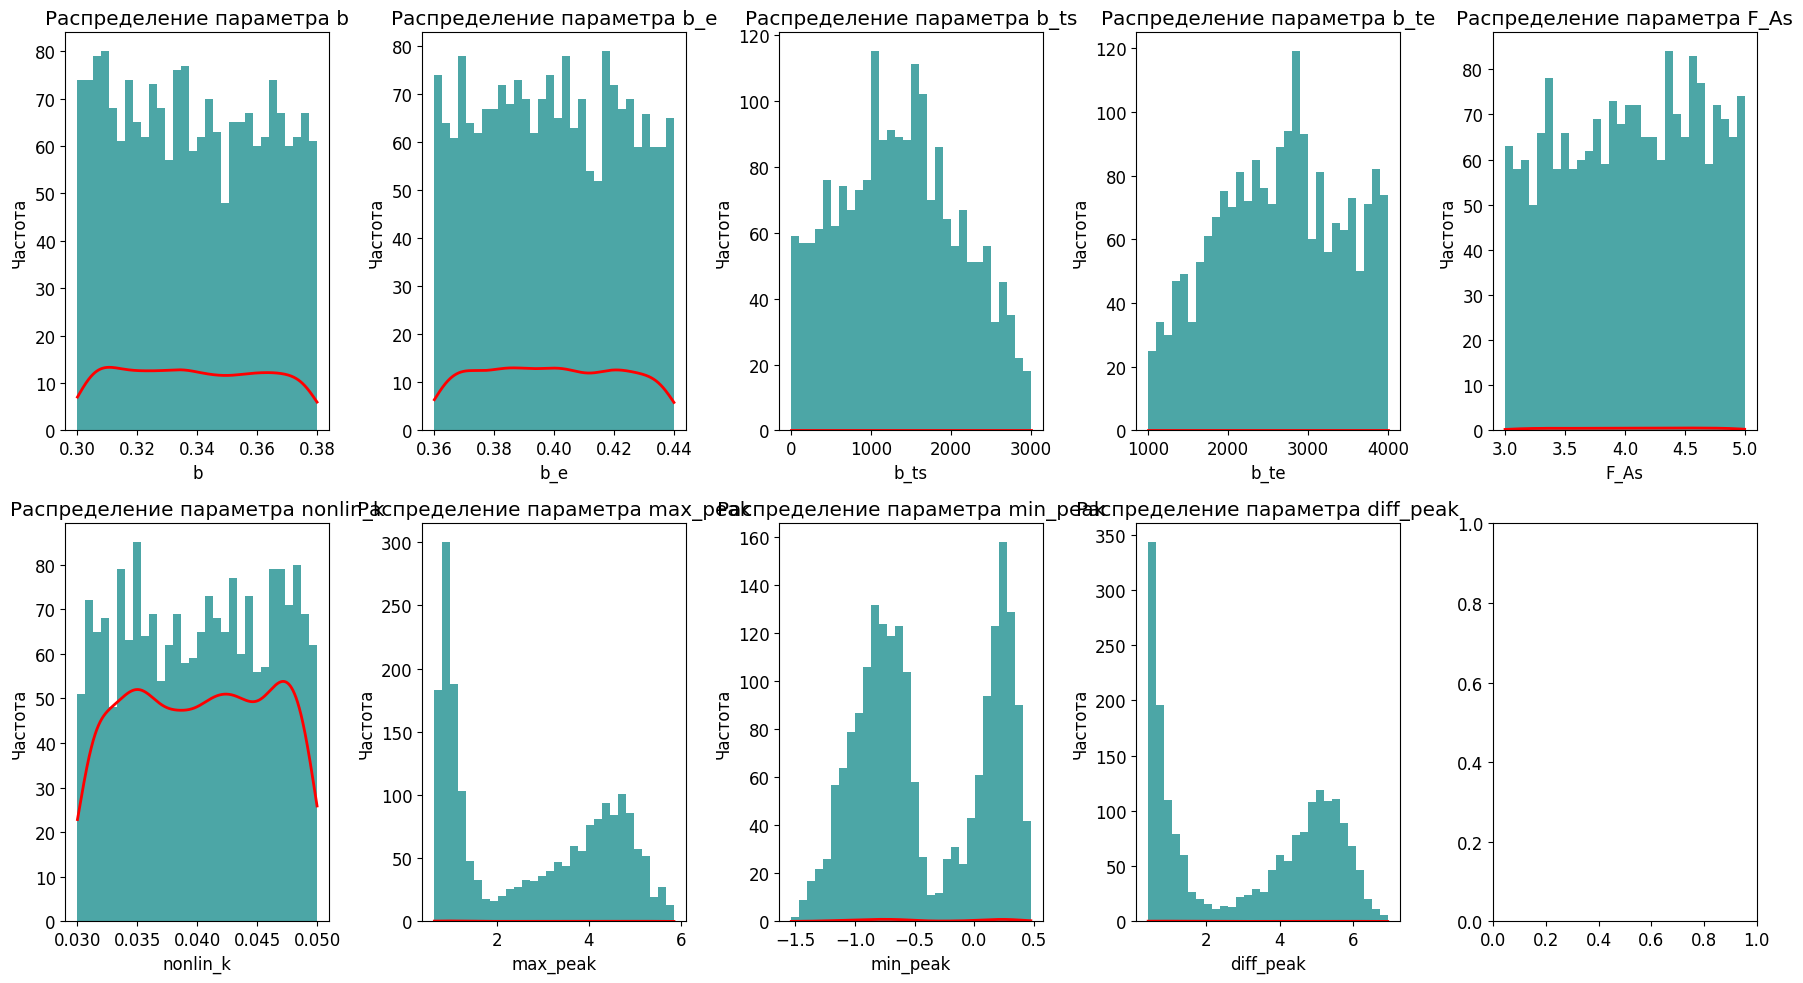

In [42]:
params_to_plot = ['b', 'b_e', 'b_ts', 'b_te', 'F_As', 'nonlin_k', 'max_peak', 'min_peak', 'diff_peak']

fig, axes = plt.subplots(2, 5, figsize=(18, 10))
axes = axes.flatten()

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    if param in df_traj.columns:
        # Гистограмма
        ax.hist(df_traj[param].dropna(), bins=30, alpha=0.7, color='teal')

        # KDE оценка плотности
        if len(df_traj[param].dropna()) > 1:
            kde = gaussian_kde(df_traj[param].dropna())
            x = np.linspace(df_traj[param].min(), df_traj[param].max(), 1000)
            ax.plot(x, kde(x), 'r-', linewidth=2)

        ax.set_title(f'Распределение параметра {param}')
        ax.set_xlabel(param)
        ax.set_ylabel('Частота')

plt.tight_layout()
plt.show()

## Корреляционный анализ

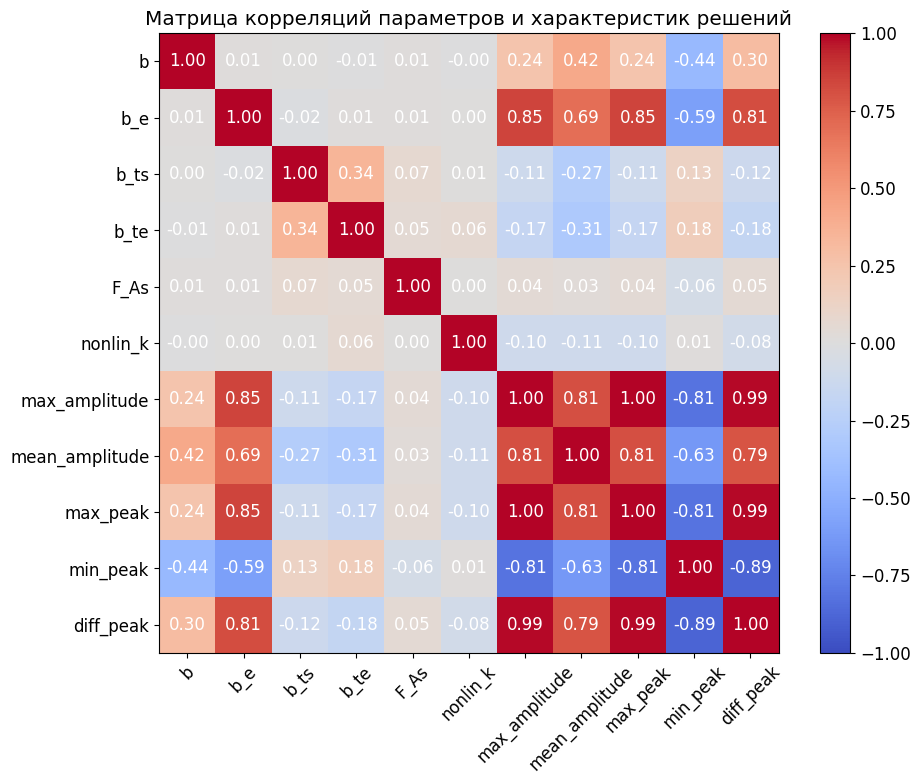

In [43]:
# Матрица корреляций
corr_matrix = df_traj[['b', 'b_e', 'b_ts', 'b_te', 'F_As', 'nonlin_k',
                        'max_amplitude', 'mean_amplitude', 'max_peak', 'min_peak', 'diff_peak']].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=45)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title('Матрица корреляций параметров и характеристик решений')

# Добавление значений корреляции
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        plt.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="white")

plt.tight_layout()
plt.show()

## Визуализация траекторий

{
    "k": 0.181,
    "d": 2.5,
    "e": 0,
    "tau": 6.283185307179586,
    "T": 6.283185307179586,
    "F_ts": 0,
    "F_te": 10,
    "F_T": 2.0943951023931953,
    "b": 0.34406383220596604,
    "b_e": 0.4166518258094484,
    "nonlin_k": 0.03581809477825889,
    "F_As": 4.785893908695309,
    "F_Ae": 4.785893908695309,
    "b_ts": 1376.7559313915087,
    "b_te": 2688.8792668003143
}


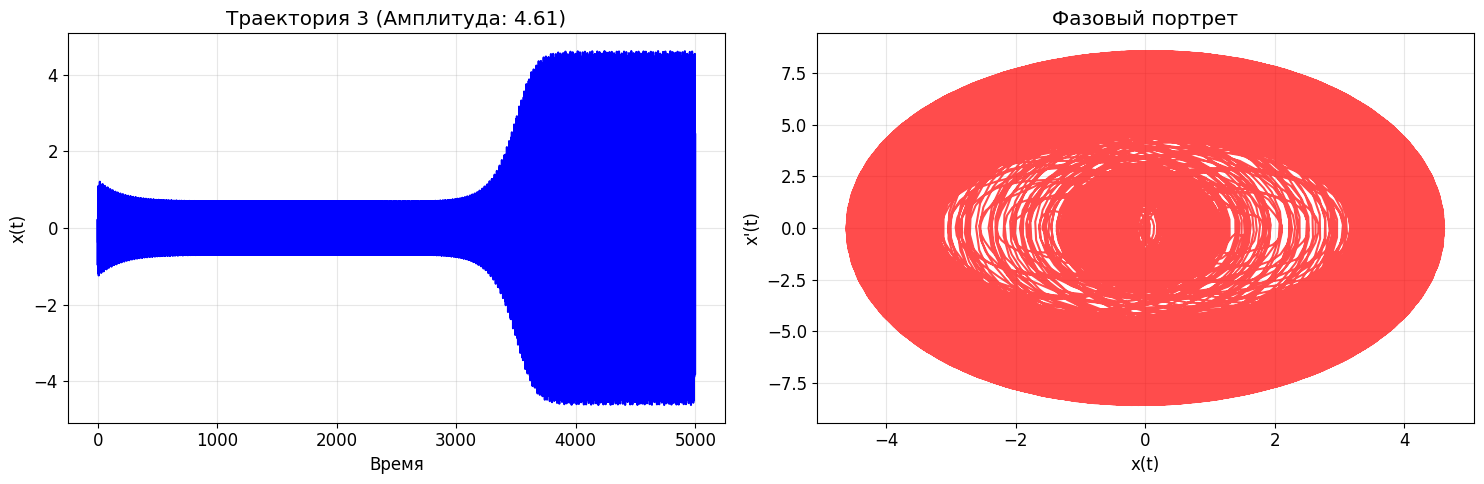

In [44]:
import json
def plot_trajectory(trajectory, ax1, ax2):
    """Визуализирует траекторию"""
    print(json.dumps(trajectory["parameters"], indent=4))
    # print("b", trajectory["parameters"]["b"])
    # print("b_e", trajectory["parameters"]["b_e"])
    t = trajectory['solution']['t']
    x = trajectory['solution']['x']
    x_dot = trajectory['solution']['x_dot']

    # Временной ряд
    ax1.plot(t, x, 'b-')
    ax1.set_xlabel('Время')
    ax1.set_ylabel('x(t)')
    ax1.set_title(f"Траектория {trajectory['id']} (Амплитуда: {trajectory['metadata']['max_amplitude']:.2f})")
    ax1.grid(True, alpha=0.3)

    # Фазовый портрет
    ax2.plot(x, x_dot, 'r-', alpha=0.7)
    ax2.set_xlabel('x(t)')
    ax2.set_ylabel("x'(t)")
    ax2.set_title('Фазовый портрет')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Выбираем случайные траектории для визуализации
sample_trajectories = []
for dataset in datasets.values():
    if dataset['trajectories']:
        # sample_trajectories.append(np.random.choice(dataset['trajectories'], size=10, replace=False))
        sample_trajectories.append(dataset['trajectories'][3])


# sample_trajectories = dataset['trajectories']

# Создаем графики
fig, axes = plt.subplots(len(sample_trajectories), 2, figsize=(15, 5*len(sample_trajectories)))

if len(sample_trajectories) == 1:
    axes = axes.reshape(1, -1)

for i, traj in enumerate(sample_trajectories):
    plot_trajectory(traj, axes[i, 0], axes[i, 1])


## Анализ зависимости амплитуды от параметров

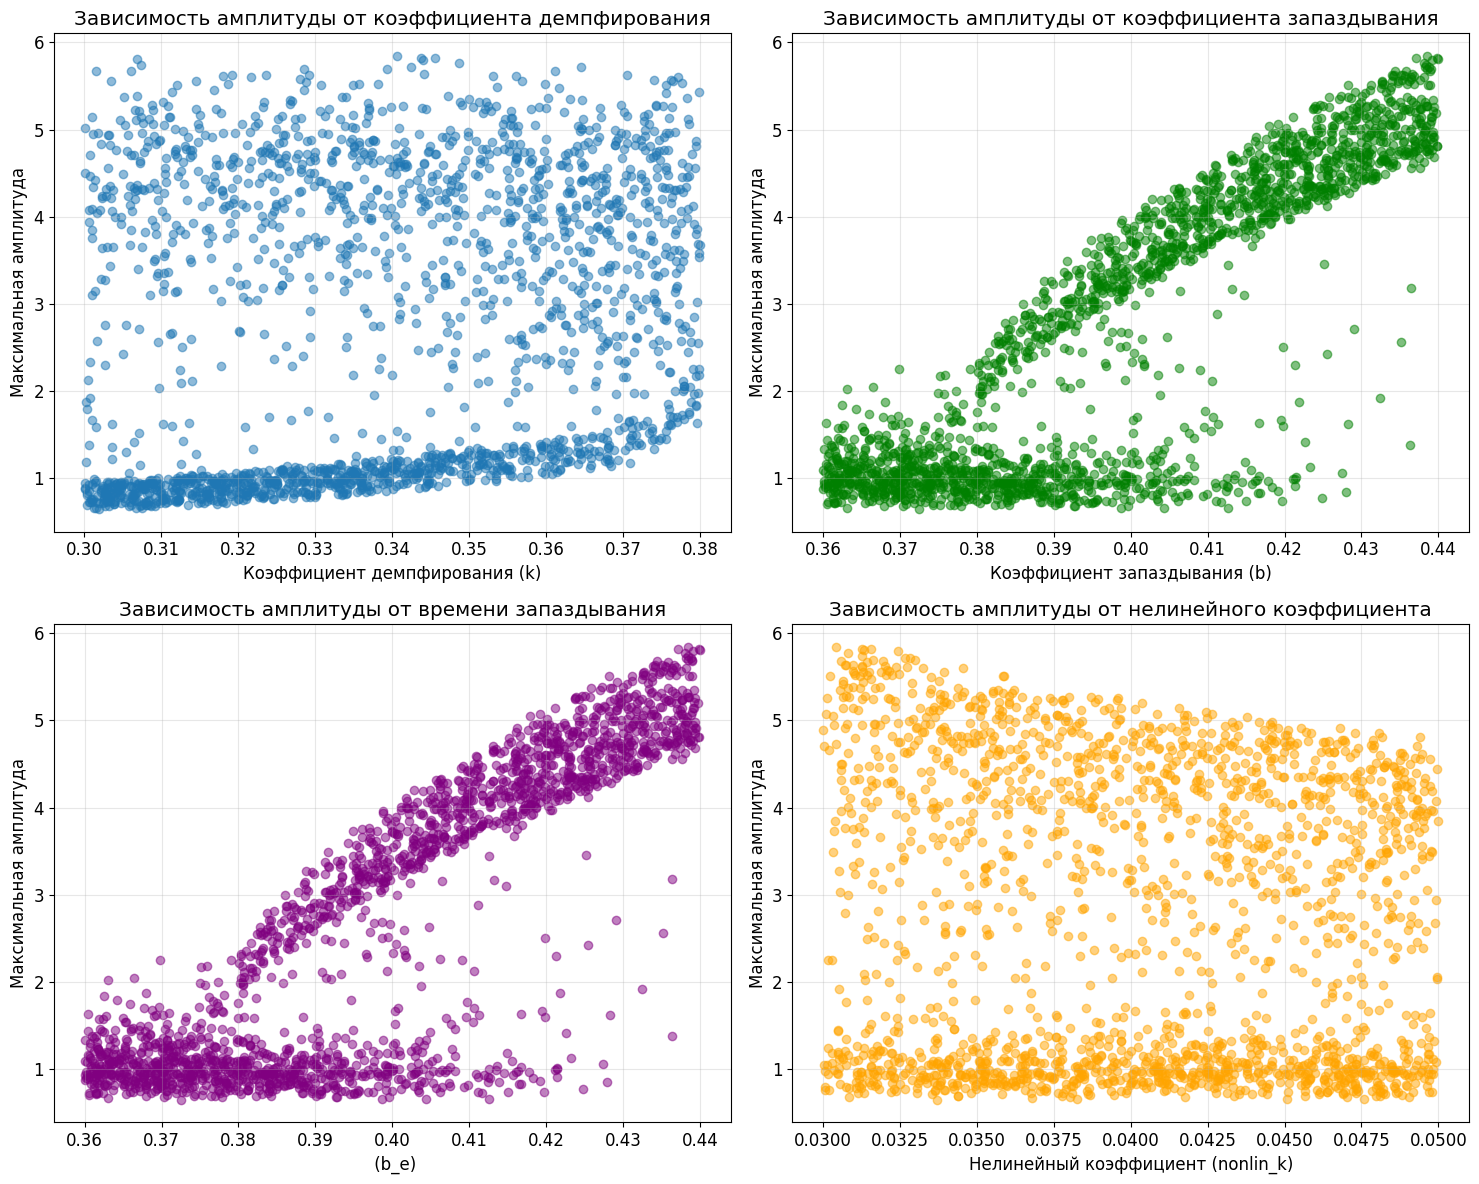

In [45]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Зависимость от коэффициента демпфирования (k)
axes[0, 0].scatter(df_traj['b'], df_traj['max_amplitude'], alpha=0.5)
axes[0, 0].set_xlabel('Коэффициент демпфирования (k)')
axes[0, 0].set_ylabel('Максимальная амплитуда')
axes[0, 0].set_title('Зависимость амплитуды от коэффициента демпфирования')
axes[0, 0].grid(True, alpha=0.3)

# Зависимость от коэффициента запаздывания (b)
axes[0, 1].scatter(df_traj['b_e'], df_traj['max_amplitude'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Коэффициент запаздывания (b)')
axes[0, 1].set_ylabel('Максимальная амплитуда')
axes[0, 1].set_title('Зависимость амплитуды от коэффициента запаздывания')
axes[0, 1].grid(True, alpha=0.3)

# Зависимость от времени запаздывания (tau)
axes[1, 0].scatter(df_traj['b_e'], df_traj['max_amplitude'], alpha=0.5, color='purple')
axes[1, 0].set_xlabel(' (b_e)')
axes[1, 0].set_ylabel('Максимальная амплитуда')
axes[1, 0].set_title('Зависимость амплитуды от времени запаздывания')
axes[1, 0].grid(True, alpha=0.3)

# Зависимость от нелинейного коэффициента (nonlin_k)
axes[1, 1].scatter(df_traj['nonlin_k'], df_traj['max_amplitude'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Нелинейный коэффициент (nonlin_k)')
axes[1, 1].set_ylabel('Максимальная амплитуда')
axes[1, 1].set_title('Зависимость амплитуды от нелинейного коэффициента')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

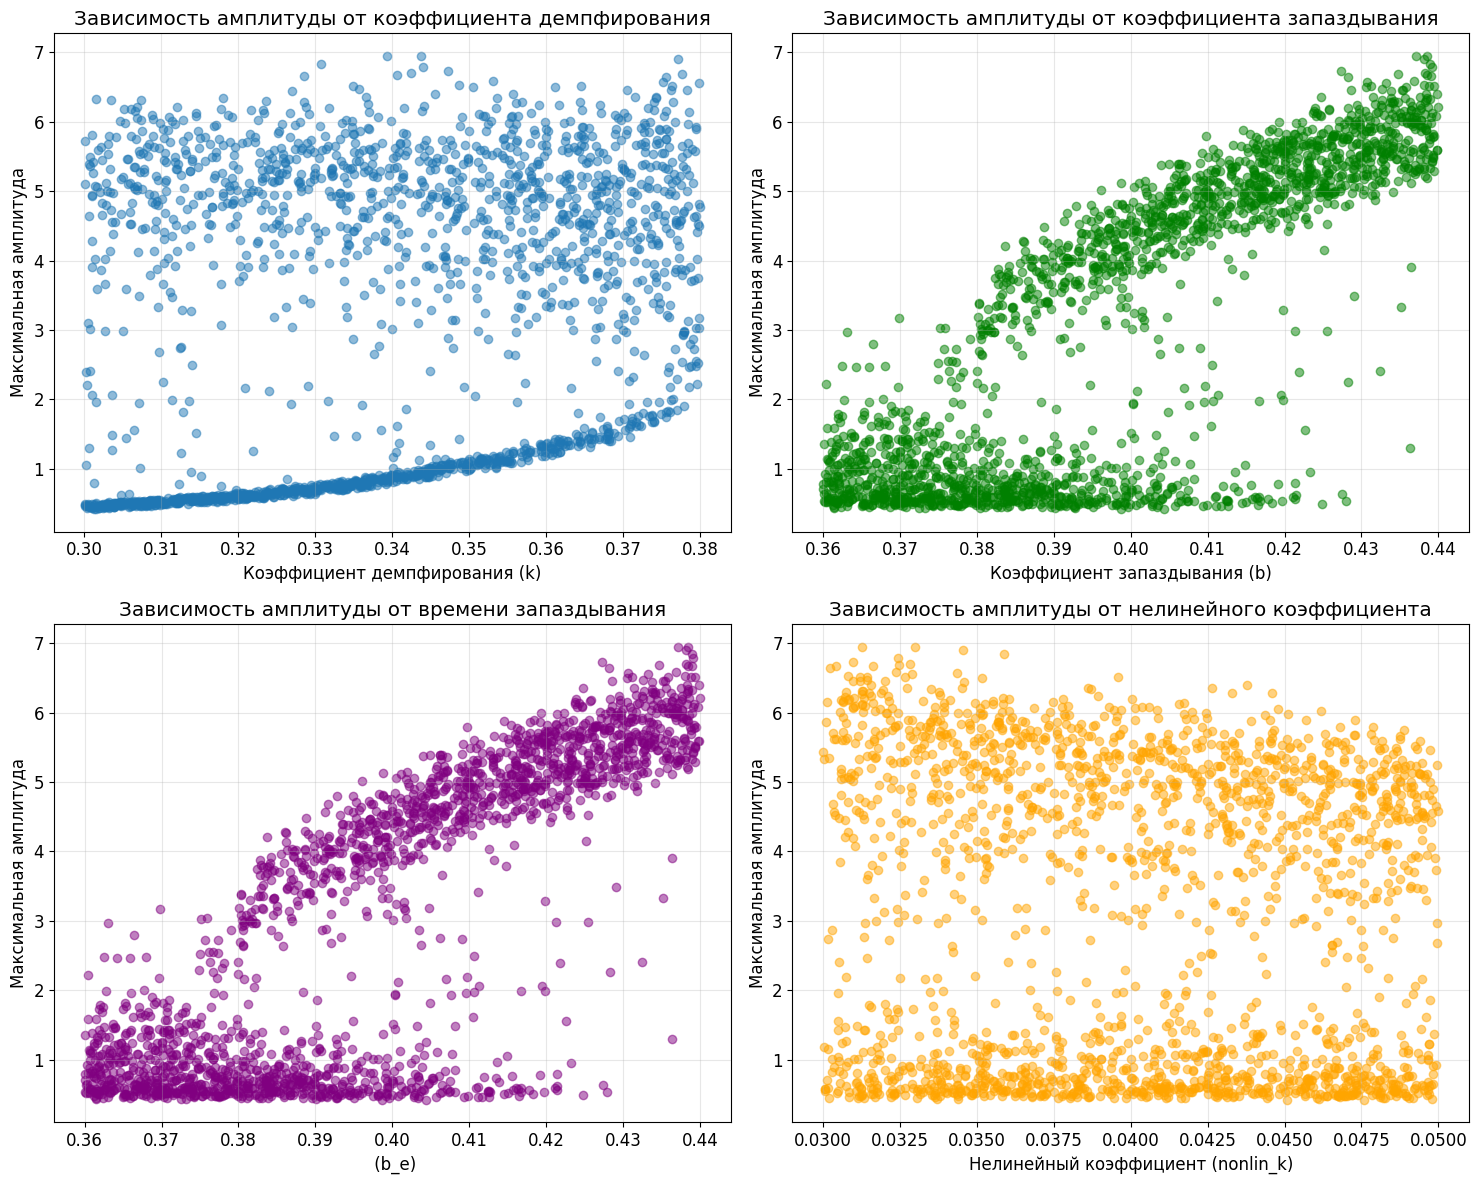

In [47]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Зависимость от коэффициента демпфирования (k)
axes[0, 0].scatter(df_traj['b'], df_traj['diff_peak'], alpha=0.5)
axes[0, 0].set_xlabel('Коэффициент демпфирования (k)')
axes[0, 0].set_ylabel('Максимальная амплитуда')
axes[0, 0].set_title('Зависимость амплитуды от коэффициента демпфирования')
axes[0, 0].grid(True, alpha=0.3)

# Зависимость от коэффициента запаздывания (b)
axes[0, 1].scatter(df_traj['b_e'], df_traj['diff_peak'], alpha=0.5, color='green')
axes[0, 1].set_xlabel('Коэффициент запаздывания (b)')
axes[0, 1].set_ylabel('Максимальная амплитуда')
axes[0, 1].set_title('Зависимость амплитуды от коэффициента запаздывания')
axes[0, 1].grid(True, alpha=0.3)

# Зависимость от времени запаздывания (tau)
axes[1, 0].scatter(df_traj['b_e'], df_traj['diff_peak'], alpha=0.5, color='purple')
axes[1, 0].set_xlabel(' (b_e)')
axes[1, 0].set_ylabel('Максимальная амплитуда')
axes[1, 0].set_title('Зависимость амплитуды от времени запаздывания')
axes[1, 0].grid(True, alpha=0.3)

# Зависимость от нелинейного коэффициента (nonlin_k)
axes[1, 1].scatter(df_traj['nonlin_k'], df_traj['diff_peak'], alpha=0.5, color='orange')
axes[1, 1].set_xlabel('Нелинейный коэффициент (nonlin_k)')
axes[1, 1].set_ylabel('Максимальная амплитуда')
axes[1, 1].set_title('Зависимость амплитуды от нелинейного коэффициента')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Сохранение результатов анализа

In [ ]:
# Сохраняем сводную информацию о датасетах
df_info.to_csv('projects/create_datasets/dataset_summary.csv', index=False)

# Сохраняем данные о траекториях
df_traj.to_csv('projects/create_datasets/trajectory_data.csv', index=False)

print("Результаты анализа сохранены в CSV файлы:")
print("- projects/create_datasets/dataset_summary.csv")
print("- projects/create_datasets/trajectory_data.csv")